In [1]:
import os

for dirname, _, _ in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/wassambaig
/kaggle/input/datasets/wassambaig/datasplits
/kaggle/input/datasets/wassambaig/datasplits/dataset_split
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val/Unknown
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val/Non_Aedes
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val/Aedes
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/train
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/train/Unknown
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/train/Non_Aedes
/kaggle/input/datasets/wassambaig/datasplits/dataset_split/train/Aedes


In [2]:
!pip install -q fastai

In [3]:
from fastai.vision.all import *

In [4]:
path = Path("/kaggle/input/datasets/wassambaig/datasplits/dataset_split")

In [5]:
dls = ImageDataLoaders.from_folder(
    path,
    train='train',
    valid='val',
    item_tfms=Resize(224),
    bs=16   # B0 can handle bigger batch
)

In [6]:
learn = vision_learner(
    dls,
    'efficientnet_b0',   # 🔥 CHANGED (IMPORTANT)
    metrics=accuracy
)

learn = learn.to_fp16()

In [7]:
learn.fine_tune(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.351318,0.255539,0.902643,01:05


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,accuracy,time
0,0.242418,0.169710,0.931415,01:16
1,0.195254,0.141644,0.944463,01:12
2,0.157701,0.132390,0.949816,01:13


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [8]:
learn.fine_tune(2)

epoch,train_loss,valid_loss,accuracy,time
0,0.222927,0.156232,0.942121,01:07


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,accuracy,time
0,0.191192,0.133902,0.947474,01:13
1,0.130066,0.131640,0.951489,01:12


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [11]:
learn.export('/kaggle/working/mosquito_classifier.pkl')

In [15]:
print(len(learn.dls.valid))

0


In [16]:
from fastai.vision.all import *

path = Path("/kaggle/input/datasets/wassambaig/datasplits/dataset_split")

dls = ImageDataLoaders.from_folder(
    path,
    train="train",
    valid="val",
    valid_pct=None,   # 🔥 IMPORTANT (prevents auto split)
    item_tfms=Resize(224),
    bs=8
)

In [17]:
print("Train size:", len(dls.train))
print("Valid size:", len(dls.valid))

Train size: 1494
Valid size: 374


In [ ]:
learn.dls = dls

In [ ]:
preds, targets = learn.get_preds(dl=dls.valid)

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get predictions (correct loader now)
preds, targets = learn.get_preds(dl=learn.dls.valid)

pred_labels = preds.argmax(dim=1).numpy()
true_labels = targets.numpy()

# -------------------------
# Accuracy
# -------------------------
acc = (pred_labels == true_labels).mean() * 100
print(f"\nAccuracy: {acc:.2f}%")

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=learn.dls.vocab,
            yticklabels=learn.dls.vocab)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()

# -------------------------
# Classification Report
# -------------------------
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=learn.dls.vocab))

AttributeError: 'NoneType' object has no attribute 'argmax'

In [19]:
learn = vision_learner(
    dls,
    'efficientnet_b0',
    metrics=accuracy
)

learn = learn.to_fp16()

In [21]:
preds, targets = learn.get_preds(dl=dls.valid)

In [23]:
print(type(preds), type(targets))
print(len(preds), len(targets))

<class 'torch.Tensor'> <class 'torch.Tensor'>
2989 2989



Accuracy: 34.43%


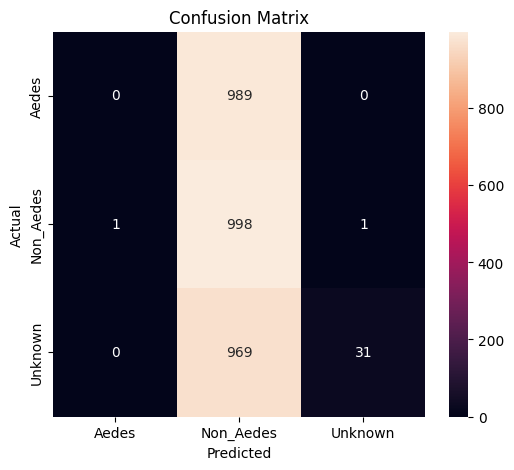


Classification Report:

              precision    recall  f1-score   support

       Aedes       0.00      0.00      0.00       989
   Non_Aedes       0.34      1.00      0.50      1000
     Unknown       0.97      0.03      0.06      1000

    accuracy                           0.34      2989
   macro avg       0.44      0.34      0.19      2989
weighted avg       0.44      0.34      0.19      2989



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pred_labels = preds.argmax(dim=1).cpu().numpy()
true_labels = targets.cpu().numpy()

# Accuracy
acc = (pred_labels == true_labels).mean() * 100
print(f"\nAccuracy: {acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=learn.dls.vocab,
            yticklabels=learn.dls.vocab)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=learn.dls.vocab))

In [25]:
from fastai.learner import load_learner
from pathlib import Path
import random
from PIL import Image
import matplotlib.pyplot as plt

# Load model
learn = load_learner('/kaggle/working/mosquito_classifier.pkl')

# Path to validation images
val_path = Path("/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val")

# Get all images
all_images = list(val_path.glob('*/*'))

# Pick random 6 images
sample_images = random.sample(all_images, 6)

# Plot predictions
plt.figure(figsize=(10,6))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)

    pred, idx, probs = learn.predict(img)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"{pred}\n{probs[idx]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

AssertionError: 

<Figure size 1000x600 with 0 Axes>

In [26]:
print("TRAIN vocab:", learn.dls.vocab)

TRAIN vocab: ['Aedes', 'Non_Aedes', 'Unknown']


In [27]:
from fastai.learner import load_learner

learn = load_learner('/kaggle/working/mosquito_classifier.pkl')

In [30]:
preds, targets = learn.get_preds()

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")



Accuracy: 67.05%


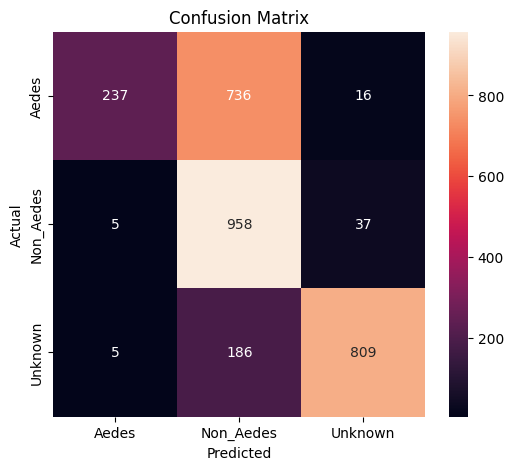


Classification Report:

              precision    recall  f1-score   support

       Aedes       0.96      0.24      0.38       989
   Non_Aedes       0.51      0.96      0.67      1000
     Unknown       0.94      0.81      0.87      1000

    accuracy                           0.67      2989
   macro avg       0.80      0.67      0.64      2989
weighted avg       0.80      0.67      0.64      2989



In [38]:
from fastai.learner import load_learner
from fastai.vision.all import *
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load trained model
learn = load_learner('/kaggle/working/mosquito_classifier.pkl')

# 🔥 RELOAD validation dataset (IMPORTANT)
path = Path("/kaggle/input/datasets/wassambaig/datasplits/dataset_split")

dls = ImageDataLoaders.from_folder(
    path,
    train='train',
    valid='val',
    valid_pct=None,
    item_tfms=Resize(224),
    bs=8
)

# Attach dataloaders
learn.dls = dls

# 🔥 NOW get predictions
preds, targets = learn.get_preds(dl=dls.valid)

# Convert
pred_labels = preds.argmax(dim=1).numpy()
true_labels = targets.numpy()

# Accuracy
acc = (pred_labels == true_labels).mean() * 100
print(f"\nAccuracy: {acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=dls.vocab,
            yticklabels=dls.vocab)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=dls.vocab))

In [35]:
dls = ImageDataLoaders.from_folder(
    path,
    train='train',
    valid='val',
    valid_pct=None,
    item_tfms=Resize(224),
    batch_tfms=Normalize.from_stats(*imagenet_stats),  # 🔥 CRITICAL
    bs=8
)

In [36]:
learn.dls = dls
preds, targets = learn.get_preds(dl=dls.valid)

In [37]:
Normalize.from_stats(*imagenet_stats)

Normalize -- {'mean': tensor([[[[0.4850]],

         [[0.4560]],

         [[0.4060]]]], device='cuda:0'), 'std': tensor([[[[0.2290]],

         [[0.2240]],

         [[0.2250]]]], device='cuda:0'), 'axes': (0, 2, 3)}
(enc:2,dec:2)

In [39]:
from fastai.learner import load_learner

learn = load_learner('/kaggle/working/mosquito_classifier.pkl')

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [40]:
from pathlib import Path

path = Path("/kaggle/input/datasets/wassambaig/datasplits/dataset_split/val")

# 🔥 IMPORTANT: use test_dl (keeps transforms intact)
dl = learn.dls.test_dl(get_image_files(path))

In [41]:
preds, _ = learn.get_preds(dl=dl)
pred_labels = preds.argmax(dim=1).numpy()

In [42]:
files = get_image_files(path)

# Extract labels from folder names
true_labels = [f.parent.name for f in files]

# Convert to index using vocab
label_to_idx = {v:k for k,v in enumerate(learn.dls.vocab)}
true_labels = np.array([label_to_idx[l] for l in true_labels])


Accuracy: 95.15%


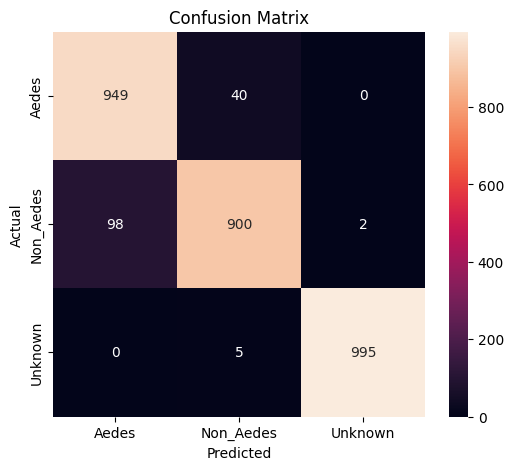


Classification Report:

              precision    recall  f1-score   support

       Aedes       0.91      0.96      0.93       989
   Non_Aedes       0.95      0.90      0.93      1000
     Unknown       1.00      0.99      1.00      1000

    accuracy                           0.95      2989
   macro avg       0.95      0.95      0.95      2989
weighted avg       0.95      0.95      0.95      2989



In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
acc = (pred_labels == true_labels).mean() * 100
print(f"\nAccuracy: {acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=learn.dls.vocab,
            yticklabels=learn.dls.vocab)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Report
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=learn.dls.vocab))